# COMP642 Machine Learning Final Project
Fantasy Football Wide Receiver (WR) Predictions\
James Jamgotchian\
S01436702

## Data
Data is sourced from the `nflreadpy` package available on the standard PyPI channel [and available on Github](https://github.com/nflverse/nflreadpy). It is a Python-port from the `nflverse-data` project which holds the [automated data releases of NFL data](https://github.com/nflverse/nflverse-data). 

In [202]:
# Basic imports to be used throughout this notebook
import nflreadpy as nfl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
%matplotlib inline

### 1. Get Data
----

#### Player Statistics Data

In [228]:
# Relevant columns for this model
COLS_TO_KEEP = ['player_id', 'player_name', 'player_display_name', 'position', 
                'season', 'week', 'season_type', 'team', 'opponent_team',
                'receptions', 'targets', 'receiving_yards', 'receiving_tds', 
                'receiving_air_yards', 'receiving_yards_after_catch', 
                'receiving_first_downs', 'receiving_epa', 'racr', 
                'target_share', 'air_yards_share', 'wopr', 
                'fantasy_points', 'fantasy_points_ppr'
               ]
# Load weekly stats for the last 3 seasons
seasons = range(2000, 2025) # [2023, 2024, 2025]
weekly_stats = nfl.load_player_stats(seasons)
weekly_stats = weekly_stats.select(COLS_TO_KEEP)

#### Player Identifying Data

In [229]:
PLAYER_COLS_TO_KEEP = ['gsis_id', 'height', 'weight', 'birth_date', 'years_of_experience']
df_players = nfl.load_players().to_pandas()
df_players = df_players[PLAYER_COLS_TO_KEEP]

#### Game Identifying Data

In [230]:
SCHED_COLS_TO_KEEP = ['season', 'week', 'home_team', 'away_team', 'gameday']
schedules = nfl.load_schedules(seasons).to_pandas()
# Only need season, week, and team to match the game date to the player
sched_lite = schedules[SCHED_COLS_TO_KEEP]

#### Play-By-Play Data

In [231]:
# PBP data used to calculate quality of offensive and defensive teams via EPA
# reference: https://www.espn.com/nfl/story/_/id/8379024/nfl-explaining-expected-points-metric
pbp = nfl.load_pbp(seasons).to_pandas()

# Calculate Weekly Team EPA (Offense and Defense)
# Offense: EPA generated by the 'posteam'
offense_stats = pbp.groupby(['posteam', 'season', 'week'])['epa'].mean().reset_index()
offense_stats.rename(columns={'posteam': 'team', 'epa': 'off_epa_weekly'}, inplace=True)

# Defense: EPA allowed by the 'defteam', specifically on passes since this is WR data
defense_stats = pbp[pbp['pass'] == 1].groupby(['defteam', 'season', 'week'])['epa'].mean().reset_index()
defense_stats.rename(columns={'defteam': 'opponent_team', 'epa': 'def_epa_weekly'}, inplace=True)

#### Filtering of data

In [232]:
## This model will only address WR's, and fantasy football only uses Regular Season games
# filter for WRs/Reg season and convert to Pandas
weekly_stats = weekly_stats.filter(weekly_stats['position'] == 'WR')
df_wr = weekly_stats.filter(weekly_stats['season_type'] == 'REG').to_pandas()

# Clean up by removing players who didn't actually play a snap
df_wr = df_wr[df_wr['receptions'] >= 0]

# Remove Rookies for this model
df_players = df_players[df_players['years_of_experience'] > 0]

#### Aggregation of all data

In [233]:
## Firstly, Merge statistical data with player data
df_master = pd.merge(
    df_wr, 
    df_players, 
    left_on='player_id', 
    right_on='gsis_id', 
    how='left'
)

# remove extraneous columns
df_master = df_master.drop(columns=['gsis_id', 'player_name', 'position', 'season_type'])

# --------------------------------------------------------------------------------------
## Second, merge the schedule info with the rest of the data to get gameday information
# Note: A player could be on the home or away team. 
# merge based on the player's team matching either side.
df_master = pd.merge(
    df_master, 
    sched_lite, 
    left_on=['season', 'week', 'team'], 
    right_on=['season', 'week', 'home_team'], # Try matching as home team
    how='left'
)

# Fill in the blanks for Away games
df_master['gameday'] = df_master['gameday'].fillna(
    pd.merge(
        df_master, 
        sched_lite, 
        left_on=['season', 'week', 'team'], 
        right_on=['season', 'week', 'away_team'], 
        how='left'
    )['gameday_y']
)

# verify that 'gameday' field is fully populated
print(f'"gameday" field has {df_master['gameday'].isna().sum()} null values')

# merge PBP data
df_master = pd.merge(df_master, offense_stats[['team', 'season', 'week', 'off_epa_weekly']], on=['team', 'season', 'week'], how='left')
df_master = pd.merge(df_master, defense_stats[['opponent_team', 'season', 'week', 'def_epa_weekly']], on=['opponent_team', 'season', 'week'], how='left')

# drop unneeded 'home'/'away' for this model
df_master = df_master.drop(columns=['home_team', 'away_team'])

"gameday" field has 2974 null values


### 2. Data Prep
-----

#### Check for Null Values

Columns with null values: ['receiving_epa', 'racr', 'target_share', 'air_yards_share', 'wopr', 'height', 'weight', 'birth_date', 'years_of_experience', 'gameday', 'off_epa_weekly']
total null values: player_id                          0
player_display_name                0
season                             0
week                               0
team                               0
opponent_team                      0
receptions                         0
targets                            0
receiving_yards                    0
receiving_tds                      0
receiving_air_yards                0
receiving_yards_after_catch        0
receiving_first_downs              0
receiving_epa                   7925
racr                            8534
target_share                   11837
air_yards_share                 8233
wopr                           14120
fantasy_points                     0
fantasy_points_ppr                 0
height                           202
weight                 

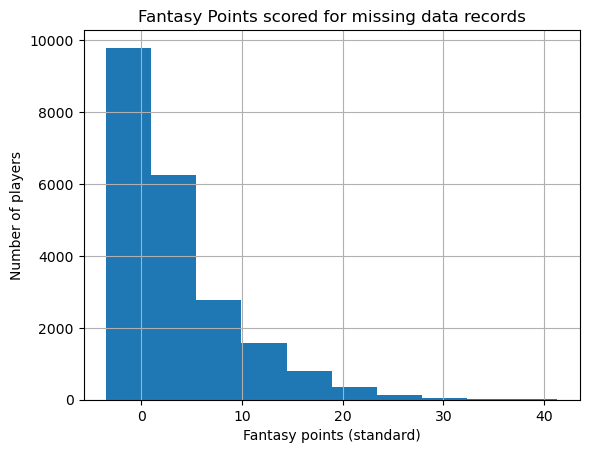

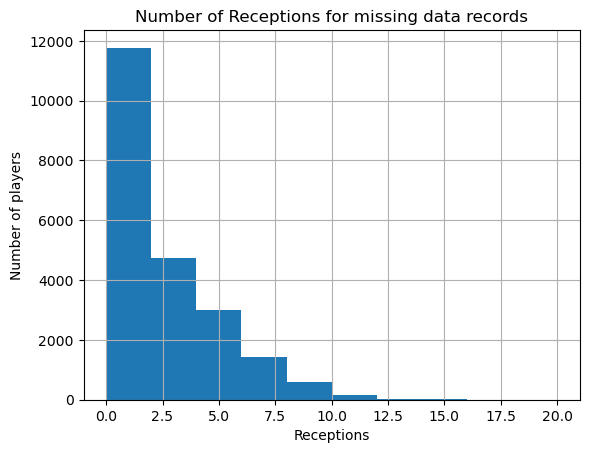

In [234]:
if (df_master.isna().any().any()):
    print(f'Columns with null values: {df_master.columns[df_master.isna().any()].tolist()}')
    print(f'total null values: {df_master.isna().sum()}')
    nv_present = True
else:
    print('No columns with null values detected.')

if nv_present:
    # plot the distribution of fantasy points for records with missing data
    # to determine their significance
    df_missing = df_master.loc[df_master.isna().any(axis=1), :]
    df_missing['fantasy_points'].hist(bins=10)
    plt.title('Fantasy Points scored for missing data records')
    plt.xlabel('Fantasy points (standard)')
    plt.ylabel('Number of players')
    # plot distribution of number of receptions for records with missing data
    plt.figure()
    df_missing['receptions'].hist(bins=10)
    plt.title('Number of Receptions for missing data records')
    plt.xlabel('Receptions')
    plt.ylabel('Number of players')

#### Null values resolution
- As can be seen by the two plots above, the majority of records with missing data appear to have minimal fantasy scores and basically zero receptions (one of the key indicators that a WR played in the game).
- It is likely these records are incomplete or corrupted, and will be completely omitted from the rest of the ML process

In [235]:
# drop the missing data after resolving it is not valid for this analysis
print(f'Number of records prior to removing nulls {len(df_master)}')
df_master = df_master.dropna()
print(f'Number of records after removing nulls {len(df_master)}')

Number of records prior to removing nulls 54554
Number of records after removing nulls 32805


#### Feature Engineering
- Add additional features to data to increase its usefulness for the model
---

##### Feature 1 - `age_at_game`
- player's age at the time of the game

In [236]:
# Convert to Datetime
df_master['birth_date'] = pd.to_datetime(df_master['birth_date'])
df_master['gameday'] = pd.to_datetime(df_master['gameday'])

# Calculate Age in Years (floating point)
# We divide by 365.25 to account for leap years
df_master['age_at_game'] = (df_master['gameday'] - df_master['birth_date']).dt.days / 365.25

print(df_master[['player_display_name', 'season', 'week', 'age_at_game']].head())

   player_display_name  season  week  age_at_game
0    Derrick Alexander    2000     1    28.826831
5         David Boston    2000     1    22.042437
7       Vincent Brisby    2000     1    29.607118
14         Cris Carter    2000     1    34.773443
16       Wayne Chrebet    2000     1    27.055441


##### Feature 2 - True Target Variable - "Half PPR" fantasy points
- Most fantasy scores are "standard" or "PPR - Points per Reception". Half PPR is a mix of both and is a common balanced approach

In [237]:
# create "Half PPR" points since that is the true target
df_master['fantasy_points_half_ppr'] = df_master[['fantasy_points', 'fantasy_points_ppr']].mean(axis=1)

##### Feature 3 & 4 - Offensive & Defensive quality

In [238]:
# Create Season-To-Date (STD) Features
# We use an expanding window shifted by 1 game so it only knows what happened BEFORE this week
def get_std_metric(df, group_col, val_col):
    return df.groupby([group_col, 'season'])[val_col].transform(
        lambda x: x.expanding().mean().shift(1)
    )

df_master['off_quality'] = get_std_metric(df_master, 'team', 'off_epa_weekly')
df_master['def_quality'] = get_std_metric(df_master, 'opponent_team', 'def_epa_weekly')
# fill Week 1 NaNs with the league average (0.0) or previous season priors
df_master['off_quality'] = df_master['off_quality'].fillna(0.0)
df_master['def_quality'] = df_master['def_quality'].fillna(0.0)

# Drop the strings, numeric "quality" metrics will be used instead
# this is similar to "One-hot encoding" but substitutes the categorical "Team" strings with their offensive/defensive quality
df_master = df_master.drop(columns=['team', 'opponent_team'])

##### Rolling Quantities 
- The model needs to learn trends from existing data prior to actual games, since that is all that will be available to predict in real life.
- Handle this by replacing with a rolling quantities of player performance metrics (in the last 3 games, across their career, etc), similar to the team quality above

In [239]:
# sort chronologically by player and week
df_master = df_master.sort_values(['player_id', 'season', 'week'])

def get_ravg(df, group_col_list, val_col, n_games=3):
    return df.groupby(group_col_list)[val_col].transform(
        lambda x: x.rolling(window=n_games, min_periods=1).mean().shift(1)
    )

def get_emed(df, group_col_list, val_col):
    return df.groupby(group_col_list)[val_col].transform(
        lambda x: x.expanding().median().shift(1)
    )

# Calculate the 3-week rolling average for each player per season
# use .shift(1) so the feature for 'Week 4' is the average of 'Weeks 1, 2, and 3'
df_master['wopr_rolling_3'] = get_ravg(df_master, ['player_id', 'season'], 'wopr', 3)
df_master['points_rm'] = get_emed(df_master, ['player_id', 'season'], 'fantasy_points_half_ppr')
df_master['coeff_var'] = df_master.groupby(['player_id', 'season'])['fantasy_points_half_ppr'] \
                                     .transform(lambda x: (x.expanding().std(ddof=0)/x.expanding().mean()).shift(1))

print(df_master.isna().sum())

print(f'Number of unique players: {len(df_master['player_id'].unique())}')

# For "Cold Start" Week 1 predictions - will always be null with rolling/expanding metrics. Fill with previous season's median
metrics_to_bridge = ['wopr', 'fantasy_points_half_ppr', 'coeff_var']

df_medians = df_master.groupby(['player_id', 'season'])[metrics_to_bridge].median().reset_index()

# Shift the Season forward by 1 
# This makes the '2024 Median' row align with the '2025' season stats
df_medians['season'] = df_medians['season'] + 1
df_medians.rename(columns={m: f'prev_med_{m}' for m in metrics_to_bridge}, inplace=True)

# Merge data back into Master Dataframe
df_master = pd.merge(
    df_master, 
    df_medians, 
    on=['player_id', 'season'], 
    how='left'
)

# Fill the Week 1 NaNs (and any other missing rolling values)
# We only want to fill the 'rolling' columns with these medians
df_master['wopr_rolling_3'] = df_master['wopr_rolling_3'].fillna(df_master['prev_med_wopr'])
df_master['points_rm'] = df_master['points_rm'].fillna(df_master['prev_med_fantasy_points_half_ppr'])
df_master['coeff_var'] = df_master['coeff_var'].fillna(df_master['prev_med_coeff_var'])

df_master = df_master.drop(columns=['prev_med_wopr', 'prev_med_fantasy_points_half_ppr', 'prev_med_coeff_var'])

# because not all data is perfectly continuous, "trend" stats like those previously calculated run into some issues
# for now, just fill NaNs with median
df_master['wopr_rolling_3'] = df_master['wopr_rolling_3'].fillna(df_master['wopr_rolling_3'].median())
df_master['points_rm'] = df_master['points_rm'].fillna(df_master['points_rm'].median())
df_master['coeff_var'] = df_master['coeff_var'].fillna(df_master['coeff_var'].median())

#df_master['wopr_rolling_3'] = df_master.groupby(['player_id', 'season'])['wopr_rolling_3'].ffill()
#df_master['points_rm'] = df_master.groupby(['player_id', 'season'])['points_rm'].ffill()
#df_master['coeff_var'] = df_master.groupby(['player_id', 'season'])['coeff_var'].ffill()
# Look for 'Internal Nulls' (Nulls that occur AFTER Week 1)
#internal_nulls = df_master[(df_master['week'] > 1) & (df_master['wopr_rolling_3'].isnull())]

#print(f"Number of unexpected nulls after Week 1: {len(internal_nulls)}")
#print(internal_nulls[['player_id', 'season', 'week', 'targets']].head(10))
#df_nans = df_master[df_master.isna().any(axis=1)]
#df_nans.hist(figsize=(15, 10))

player_id                         0
player_display_name               0
season                            0
week                              0
receptions                        0
targets                           0
receiving_yards                   0
receiving_tds                     0
receiving_air_yards               0
receiving_yards_after_catch       0
receiving_first_downs             0
receiving_epa                     0
racr                              0
target_share                      0
air_yards_share                   0
wopr                              0
fantasy_points                    0
fantasy_points_ppr                0
height                            0
weight                            0
birth_date                        0
years_of_experience               0
gameday                           0
off_epa_weekly                    0
def_epa_weekly                    0
age_at_game                       0
fantasy_points_half_ppr           0
off_quality                 

In [240]:
nv_present = False
if (df_master.isna().any().any()):
    print(f'Columns with null values: {df_master.columns[df_master.isna().any()].tolist()}')
    print(f'total null values: {df_master.isna().sum()}')
    nv_present = True
else:
    print('No columns with null values detected.')

if nv_present:
    # plot the distribution of fantasy points for records with missing data
    # to determine their significance
    df_missing = df_master.loc[df_master.isna().any(axis=1), :]
    df_missing['fantasy_points'].hist(bins=10)
    plt.title('Fantasy Points scored for missing data records')
    plt.xlabel('Fantasy points (standard)')
    plt.ylabel('Number of players')
    # plot distribution of number of receptions for records with missing data
    plt.figure()
    df_missing['receptions'].hist(bins=10)
    plt.title('Number of Receptions for missing data records')
    plt.xlabel('Receptions')
    plt.ylabel('Number of players')

# Check if any value in the entire DataFrame is infinite
#has_inf = np.isinf(df_master[['wopr_rolling_3', 'points_rm', 'coeff_var']]).values.any()
#print(f"Does the DataFrame have any infinite values? {has_inf}") # Output: True

# Count total infinite values
#inf_count = np.isinf(df_master).values.sum()
#print(f"Total count of infinite values: {inf_count}") # Output: 2

No columns with null values detected.


array([[<Axes: title={'center': 'season'}>,
        <Axes: title={'center': 'week'}>,
        <Axes: title={'center': 'height'}>],
       [<Axes: title={'center': 'weight'}>,
        <Axes: title={'center': 'years_of_experience'}>,
        <Axes: title={'center': 'age_at_game'}>],
       [<Axes: title={'center': 'fantasy_points_half_ppr'}>,
        <Axes: title={'center': 'off_quality'}>,
        <Axes: title={'center': 'def_quality'}>],
       [<Axes: title={'center': 'wopr_rolling_3'}>,
        <Axes: title={'center': 'points_rm'}>,
        <Axes: title={'center': 'coeff_var'}>]], dtype=object)

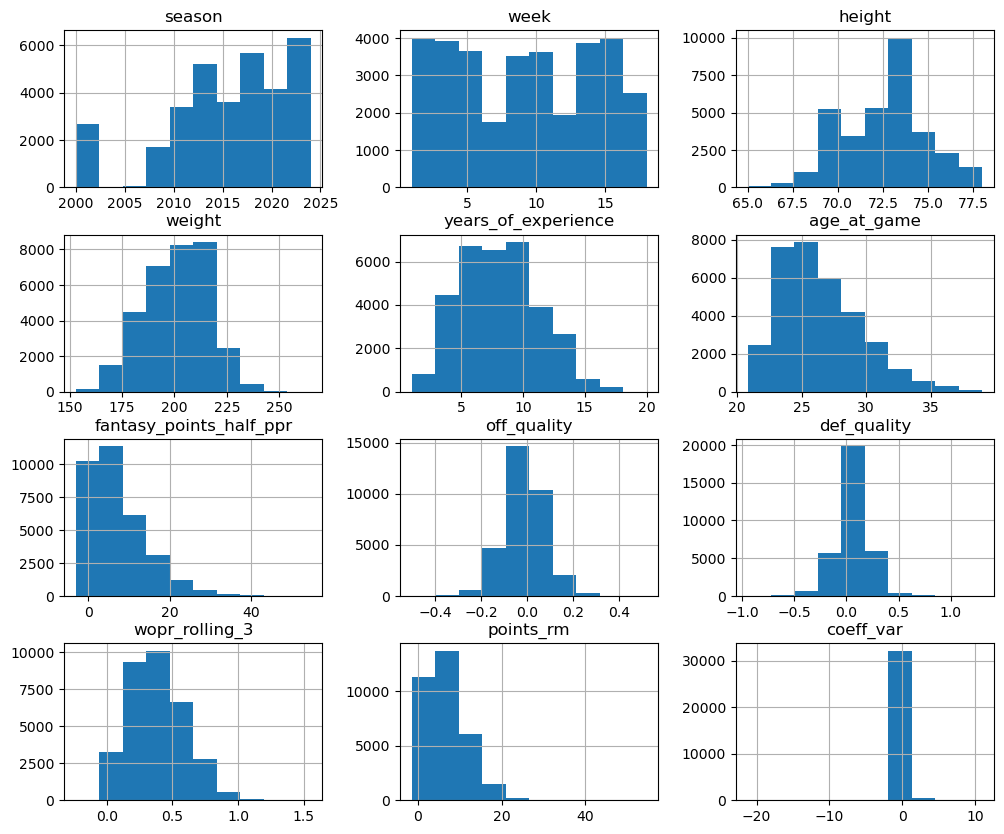

In [241]:
# removing unneeded columns that were not calculated for predictive model.
# These are first candidates for later improvements to give the model more granularity or explore relationships between variables
df_final = df_master.drop(columns=['player_id', 
                                   'receptions', 
                                   'targets', 
                                   'receiving_yards', 
                                   'receiving_air_yards',
                                   'receiving_yards_after_catch',
                                   'receiving_first_downs',
                                   'receiving_epa',
                                   'racr',
                                   'target_share',
                                   'air_yards_share',
                                   'wopr',
                                   'birth_date',
                                   'gameday',
                                   'receiving_tds',
                                   'off_epa_weekly',
                                   'def_epa_weekly',
                                   'fantasy_points',
                                   'fantasy_points_ppr'
                                  ]
                         )

df_final.hist(figsize=(12,10))

In [254]:
df_final['coeff_var'].mean()

np.float64(0.5948726331478809)

#### Data Distribution notes
- Many of these chosen parameters have large and varied distributions, although not every one possesses a true normal distribution. This will be something to keep in mind as hyperparameters are chosen
- There are two notable gaps - firstly, in `season`, there is minimal data between 2000 and 2010. It may be worth considering removing those seasons from this training set altogether.
    - Secondly, there are significant dips in the availability of data for players between Weeks 5 & 10, and then 10 & 15. This is likely due to the multitude of injuries sustained in the NFL every year, which often occur in the middle of the season.
- Lastly, the `coeff_var` appears to mostly be centered between 0 and 1, which is expected. This is a case where scaling will play an important factor in leveling the importance of each feature

#### Data Transformations

In [242]:
df_final.info()
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 32805 entries, 0 to 32804
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   player_display_name      32805 non-null  str    
 1   season                   32805 non-null  int32  
 2   week                     32805 non-null  int32  
 3   height                   32805 non-null  float64
 4   weight                   32805 non-null  float64
 5   years_of_experience      32805 non-null  float64
 6   age_at_game              32805 non-null  float64
 7   fantasy_points_half_ppr  32805 non-null  float64
 8   off_quality              32805 non-null  float64
 9   def_quality              32805 non-null  float64
 10  wopr_rolling_3           32805 non-null  float64
 11  points_rm                32805 non-null  float64
 12  coeff_var                32805 non-null  float64
dtypes: float64(10), int32(2), str(1)
memory usage: 3.4 MB
<class 'pandas.DataFrame'>
RangeI

##### Normalization

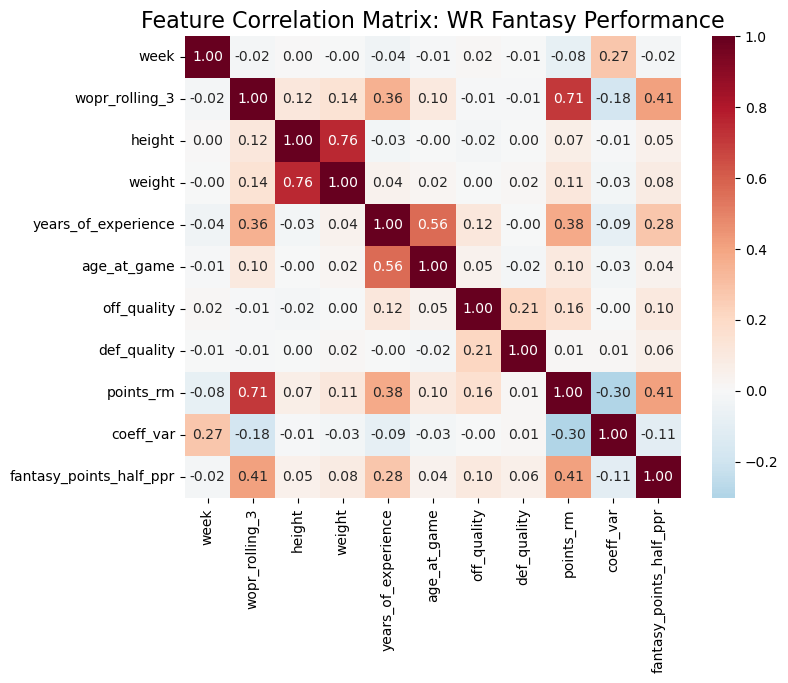

In [244]:
# Select Final Feature set
FEATURES = ['week',  # capture in-season ephemeral variation
            'wopr_rolling_3',  # Weighted Opportunity Ranking - capture how much of the team's offense this player is carrying
            'height', # capture physical characteristics - i.e. taller players tend to do better
            'weight', # capture physical characteristics - i.e. heavier players tend to get more points to running further
            'years_of_experience', # capture maturity and change from season to season
            'age_at_game', # capture physical characteristics - i.e. decline with age or prime seasons
            'off_quality', # capture how well this team is performing as a whole
            'def_quality', # capture whether the opposing team has noticeable effects on performance for others
           'points_rm', # rolling median of fantasy points scored - capture this player's historical performances and gives a sense of "who" the player is
            'coeff_var', # coefficient of variation (stdev/mean) of this player's points - capture their historical volatility
           ]
TARGET = 'fantasy_points_half_ppr'

scaler = StandardScaler()

# We only scale the features, usually leaving the target in its original units for interpretability
df_scaled = pd.DataFrame(scaler.fit_transform(df_final[FEATURES]), columns=FEATURES)
df_scaled[TARGET] = df_final[TARGET].values

# 4. Generate the Correlation Matrix
plt.figure(figsize=(8, 6))
correlation_matrix = df_scaled.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix: WR Fantasy Performance', fontsize=16)
plt.show()

- here we see some expected correlations, such as height & weight being positively correlated, rolling median points (`points_rm`) positively correlated with `wopr_rolling_3` and `fantasy_points_half_ppr`, and some additional interesting points like `week` and `coeff_var` being positively correlated - this makes sense because as the season goes on, the physical toll often leads to players having wild volatility.

In [245]:
# sort chronologically by player and week
df_master = df_master.sort_values(['player_id', 'season', 'week'])

df_master.to_csv('WRs_2023-2025.csv')
print(f"Successfully loaded and saved {len(df_master)} game logs for Wide Receivers")

Successfully loaded and saved 32805 game logs for Wide Receivers


### 3. Data Visualization
----

In [246]:
print(len(df_master['player_display_name'].unique()))

1077


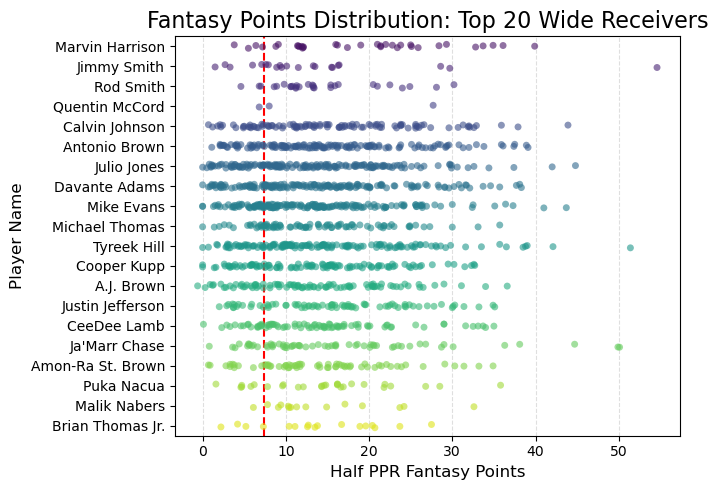

In [247]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the top 20 WRs by average points to keep the chart readable
top_20_names = df_master.groupby('player_display_name')['fantasy_points_half_ppr'].mean().nlargest(20).index
df_plot = df_master[df_master['player_display_name'].isin(top_20_names)]

# 2. Create the Strip Plot
plt.figure(figsize=(7, 5))
sns.stripplot(
    data=df_plot, 
    x='fantasy_points_half_ppr', 
    y='player_display_name', 
    hue='player_display_name',  # Adds color variety
    jitter=True,        # Spreads dots out so they don't overlap perfectly
    alpha=0.6,          # Makes dots slightly transparent
    palette='viridis',
    legend=False
)

# 3. Add a Mean Line for context
plt.axvline(df_master['fantasy_points_half_ppr'].mean(), color='red', linestyle='--', label='League Average')

plt.title('Fantasy Points Distribution: Top 20 Wide Receivers', fontsize=16)
plt.xlabel('Half PPR Fantasy Points', fontsize=12)
plt.ylabel('Player Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

Text(0.5, 1.0, 'Distribution of WR Fantasy Points (The Regression Target)')

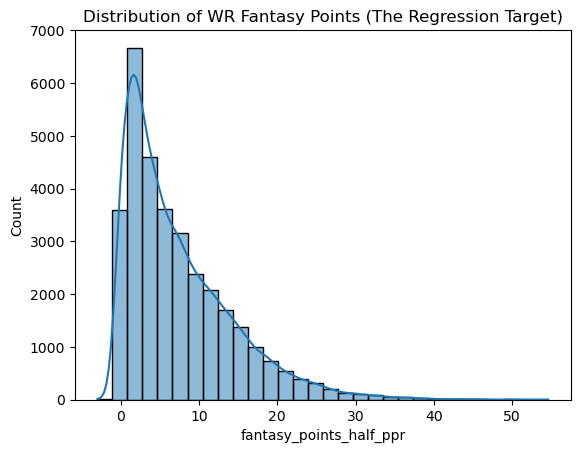

In [248]:
sns.histplot(df_master['fantasy_points_half_ppr'], bins=30, kde=True)
plt.title('Distribution of WR Fantasy Points (The Regression Target)')

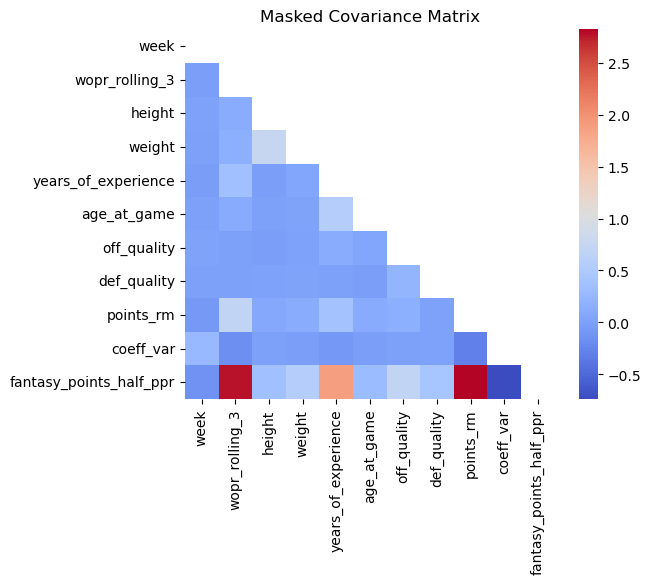

In [249]:
cov_matrix = df_scaled.cov()
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(cov_matrix, dtype=bool))

plt.figure()
sns.heatmap(cov_matrix, fmt='.1f', cmap='coolwarm', mask=mask, square=True)
plt.title('Masked Covariance Matrix')
plt.show()

- As expected, the two highest contributors to `fantasy_points_half_ppr` are the previous performance `points_rm` and `wopr` or the opportunities a player has. Other factors do have some positive influence, but are not as large as these others. Notably, `coeff_var`, or the player's volatility, has a negative effect on performance - which, is another positive sign that the chosen features help to capture the nuance of picking valuable players.